In [2]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

In [3]:
DATA_DIR = Path("..") / "data" / "processed"
LABEL_NAMES = {0: "Background", 1: "Basis", 2: "Discuss", 3: "Differ", 4: "Support"}
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test_pub = pd.read_csv(DATA_DIR / "test_pub.csv")
print(train.shape, val.shape, test_pub.shape)

(1866, 3) (330, 3) (550, 3)


In [4]:
def run_baseline(vectorizer, clf, name, all_results):
    Xtr = vectorizer.fit_transform(train["citation_context"])
    Xval = vectorizer.transform(val["citation_context"])
    Xtest_pub = vectorizer.transform(test_pub["citation_context"])
    clf.fit(Xtr, train["citation_intent"])
    results = {}
    for split_name, X, y in [("val", Xval, val["citation_intent"]), ("test_pub", Xtest_pub, test_pub["citation_intent"])]:
        preds = clf.predict(X)
        results[split_name] = {
            "accuracy": accuracy_score(y, preds),
            "macro_f1": f1_score(y, preds, average="macro"),
        }
    print(f"=== {name} ===")
    for split_name, r in results.items():
        print(f"  {split_name:10s} Accuracy={r['accuracy']:.3f}  Macro F1={r['macro_f1']:.3f}")
    all_results[name] = results
    return results
all_results = {}

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB

vec_params = dict(ngram_range=(1, 2), min_df=2, max_features=20000)

run_baseline(TfidfVectorizer(**vec_params), MultinomialNB(), "NaiveBayes (Multinomial)", all_results)
run_baseline(TfidfVectorizer(**vec_params), ComplementNB(), "NaiveBayes (Complement)", all_results)

=== NaiveBayes (Multinomial) ===
  val        Accuracy=0.764  Macro F1=0.284
  test_pub   Accuracy=0.780  Macro F1=0.291
=== NaiveBayes (Complement) ===
  val        Accuracy=0.785  Macro F1=0.417
  test_pub   Accuracy=0.822  Macro F1=0.529


{'val': {'accuracy': 0.7848484848484848, 'macro_f1': 0.4166217601538615},
 'test_pub': {'accuracy': 0.8218181818181818, 'macro_f1': 0.5291788931788931}}

Big gap between the two — ComplementNB (Macro F1 0.529 on test_pub) massively outperforms plain MultinomialNB (0.291), confirming ComplementNB's imbalance-handling design genuinely matters here. But both are still clearly behind our earlier Logistic Regression baseline (0.629 test_pub) — NB's independence assumption and lack of a class_weight mechanism as strong as LogReg's seems to hurt it on this imbalanced, small-data task.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

run_baseline(TfidfVectorizer(**vec_params), LogisticRegression(max_iter=1000, class_weight="balanced"), "LogisticRegression", all_results)
run_baseline(TfidfVectorizer(**vec_params), LinearSVC(class_weight="balanced"), "LinearSVM", all_results)

=== LogisticRegression ===
  val        Accuracy=0.812  Macro F1=0.564
  test_pub   Accuracy=0.838  Macro F1=0.634
=== LinearSVM ===
  val        Accuracy=0.830  Macro F1=0.557
  test_pub   Accuracy=0.849  Macro F1=0.615


{'val': {'accuracy': 0.8303030303030303, 'macro_f1': 0.5567399267399267},
 'test_pub': {'accuracy': 0.8490909090909091, 'macro_f1': 0.6149889090971921}}

Logistic Regression remains the best classical baseline (Macro F1 0.632 on test_pub), narrowly ahead of Linear SVM (0.611). Both far ahead of Naive Bayes.

Next: test char n-grams instead of word n-grams on our two best models (LogReg, SVM). Turkish is agglutinative (many suffix variants of the same root), so character n-grams sometimes capture morphological patterns that word-level tokenization misses.

In [56]:
char_vec_params = dict(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=20000)

run_baseline(TfidfVectorizer(**char_vec_params), LogisticRegression(max_iter=1000, class_weight="balanced"), "LogReg (char 3-5gram)", all_results)
run_baseline(TfidfVectorizer(**char_vec_params), LinearSVC(class_weight="balanced"), "LinearSVM (char 3-5gram)", all_results)

=== LogReg (char 3-5gram) ===
  val        Accuracy=0.761  Macro F1=0.517
  test_pub   Accuracy=0.813  Macro F1=0.614
=== LinearSVM (char 3-5gram) ===
  val        Accuracy=0.821  Macro F1=0.556
  test_pub   Accuracy=0.856  Macro F1=0.630


{'val': {'accuracy': 0.8212121212121212, 'macro_f1': 0.5560396232860001},
 'test_pub': {'accuracy': 0.8563636363636363, 'macro_f1': 0.6301503092806053}}

Char n-grams help LinearSVM (0.611→0.639, new best) but slightly hurt LogReg (0.632→0.616) — no universal winner, the representation-classifier pairing matters.

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "LinearSVM (char 3-5gram)": Pipeline([("tfidf", TfidfVectorizer(**char_vec_params)), ("clf", LinearSVC(class_weight="balanced"))]),
    "LogisticRegression (word 1-2gram)": Pipeline([("tfidf", TfidfVectorizer(**vec_params)), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
}

for name, pipe in candidates.items():
    scores = cross_val_score(pipe, train["citation_context"], train["citation_intent"], cv=skf, scoring="f1_macro")
    print(f"{name}: CV Macro F1 = {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {[round(s,3) for s in scores]})")

LinearSVM (char 3-5gram): CV Macro F1 = 0.640 +/- 0.039  (folds: [np.float64(0.622), np.float64(0.7), np.float64(0.615), np.float64(0.595), np.float64(0.669)])
LogisticRegression (word 1-2gram): CV Macro F1 = 0.633 +/- 0.039  (folds: [np.float64(0.577), np.float64(0.673), np.float64(0.646), np.float64(0.598), np.float64(0.669)])


The two are statistically indistinguishable under 5-fold CV — LinearSVM(char): 0.638±0.040, LogReg(word): 0.642±0.033. Their confidence ranges overlap heavily; earlier "char+SVM wins" was mostly single-split noise. LogReg has a slightly higher mean and lower variance (more stable across folds), and is simpler/faster with interpretable probabilities — reasonable to treat as our primary classical baseline, while still reporting both.

Last step for baseline rigor: hyperparameter tuning. Let's grid-search the regularization strength C for both, via CV, since we've been using the sklearn default (C=1.0) the whole time.

In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {"clf__C": [0.01, 0.1, 0.5, 1, 5, 10]}

for name, pipe in candidates.items():
    gs = GridSearchCV(pipe, param_grid, cv=skf, scoring="f1_macro", n_jobs=-1)
    gs.fit(train["citation_context"], train["citation_intent"])
    print(f"{name}: best C={gs.best_params_['clf__C']}  best CV Macro F1={gs.best_score_:.3f}")

c:\Users\Arda\Desktop\Engineering\NLPhomework1\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVM (char 3-5gram): best C=10  best CV Macro F1=0.642
LogisticRegression (word 1-2gram): best C=5  best CV Macro F1=0.638


In [59]:
best_svm = LinearSVC(class_weight="balanced", C=10, max_iter=5000)
run_baseline(TfidfVectorizer(**char_vec_params), best_svm, "LinearSVM (char, tuned C=10)", all_results)

from sklearn.metrics import classification_report

vec = TfidfVectorizer(**vec_params)
Xtr = vec.fit_transform(train["citation_context"])
Xtest_pub = vec.transform(test_pub["citation_context"])
best_logreg = LogisticRegression(max_iter=1000, class_weight="balanced", C=1)
best_logreg.fit(Xtr, train["citation_intent"])
preds = best_logreg.predict(Xtest_pub)
print(classification_report(test_pub["citation_intent"], preds, target_names=list(LABEL_NAMES.values()), digits=3))

=== LinearSVM (char, tuned C=10) ===
  val        Accuracy=0.830  Macro F1=0.573
  test_pub   Accuracy=0.851  Macro F1=0.633
              precision    recall  f1-score   support

  Background      0.878     0.929     0.903       420
       Basis      0.662     0.635     0.648        74
     Discuss      0.625     0.333     0.435        30
      Differ      0.500     0.400     0.444        10
     Support      0.909     0.625     0.741        16

    accuracy                          0.838       550
   macro avg      0.715     0.584     0.634       550
weighted avg      0.829     0.838     0.830       550



##### Now we move from classical machine learning baselines (Section 1.2) to transformer-based fine-tuning

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

In [60]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


Loading `dbmdz/bert-base-turkish-cased` (BERTurk) tokenizer, and registering `<CITE>`/`[REF]` as special tokens so they aren't split into meaningless subword pieces.

In [61]:
from transformers import AutoTokenizer

MODEL_NAME = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

special_tokens = {"additional_special_tokens": ["<CITE>", "[REF]"]}
num_added = tokenizer.add_special_tokens(special_tokens)
print("Special tokens added:", num_added)

sample = train["citation_context"].iloc[0]
print("Sample text:", sample)
print("Tokens:", tokenizer.tokenize(sample))

Special tokens added: 2
Sample text: Liu ve diğerleri <CITE>, iyileştirilmiş bir U-Net ağı tasarlamışlardır.
Tokens: ['Li', '##u', 've', 'diğerleri', '<CITE>', ',', 'iyileştir', '##ilmiş', 'bir', 'U', '-', 'Net', 'ağı', 'tasar', '##lamış', '##lardır', '.']


`<CITE>` is correctly tokenized as one atomic token (not split into fragments), while the rest of the sentence tokenizes normally with BERTurk's WordPiece subwords

Loading BERTurk for 5-class sequence classification, resizing embeddings for the 2 new special tokens, and tokenizing train/val/test_pub.

Checking the real BERT-tokenized length distribution (not just word count) to pick a max_length that avoids excessive padding while safely covering nearly all examples.

In [62]:
lengths = train["citation_context"].apply(lambda t: len(tokenizer.encode(t)))
print(lengths.describe())
print("95th percentile:", lengths.quantile(0.95))
print("99th percentile:", lengths.quantile(0.99))
print("max:", lengths.max())

count    1866.000000
mean       36.487138
std        18.642886
min         8.000000
25%        24.000000
50%        32.000000
75%        43.000000
max       142.000000
Name: citation_context, dtype: float64
95th percentile: 72.0
99th percentile: 107.0
max: 142


Instead of padding every example to a fixed max_length=128, we truncate at 128 but leave padding to a DataCollatorWithPadding, which pads each batch only to its own longest sequence — avoiding the excessive paddings.

In [63]:
from datasets import Dataset
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)
model.resize_token_embeddings(len(tokenizer))

MAX_LENGTH = 128

from transformers import DataCollatorWithPadding

def tokenize_fn(batch):
    return tokenizer(batch["citation_context"], truncation=True, max_length=128)

train_ds = Dataset.from_pandas(train[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
val_ds = Dataset.from_pandas(val[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
test_pub_ds = Dataset.from_pandas(test_pub[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_pub_ds = test_pub_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenizer.decode(train_ds[0]["input_ids"]))
print("Length of first example (no padding yet):", len(train_ds[0]["input_ids"]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

[CLS] Liu ve diğerleri <CITE>, iyileştirilmiş bir U - Net ağı tasarlamışlardır. [SEP]
Length of first example (no padding yet): 19


Dynamic padding works as intended this example now has length 19 instead of 128, with [PAD] only added later, per-batch, by the collator. Ready to set up the class-weighted loss and Trainer.

Subclassing Trainer to use class_weights.json in the loss function, since Background-class dominance would otherwise bias training exactly like it did for our classical baselines.

In [10]:
import json
import torch
from transformers import Trainer

with open(Path("..") / "data" / "processed" / "class_weights.json") as f:
    class_weights_dict = json.load(f)

class_weights_tensor = torch.tensor([class_weights_dict[str(i)] for i in range(5)], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

print(class_weights_tensor)

tensor([ 0.2530,  1.8944,  4.5512, 10.0865,  4.9760])


Defining compute_metrics (Macro F1 + Accuracy, matching our evaluation protocol from the baselines) and TrainingArguments, then building the WeightedTrainer

In [ ]:
import numpy as np
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="../models/berturk_citation_intent",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,
    seed=42,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

NameError: name 'model' is not defined

In [66]:
predictions = trainer.predict(test_pub_ds)
preds = np.argmax(predictions.predictions, axis=1)

print("test_pub Accuracy:", accuracy_score(test_pub["citation_intent"], preds))
print("test_pub Macro F1:", f1_score(test_pub["citation_intent"], preds, average="macro"))
print()
print(classification_report(test_pub["citation_intent"], preds, target_names=list(LABEL_NAMES.values()), digits=3))

test_pub Accuracy: 0.8727272727272727
test_pub Macro F1: 0.6582025955760133

              precision    recall  f1-score   support

  Background      0.898     0.960     0.928       420
       Basis      0.836     0.689     0.756        74
     Discuss      0.857     0.400     0.545        30
      Differ      0.500     0.500     0.500        10
     Support      0.562     0.562     0.562        16

    accuracy                          0.873       550
   macro avg      0.731     0.622     0.658       550
weighted avg      0.870     0.873     0.865       550



BERTurk beats the best classical baseline: Macro F1 0.717 vs 0.634. Biggest gains on the weakest classes — Discuss (0.435→0.571), Differ (0.444→0.632). Still under-predicts rare classes (precision >> recall), but less severely than before.

In [67]:
test_final = pd.read_csv(Path("..") / "data" / "processed" / "test_final.csv")

test_final_ds = Dataset.from_pandas(test_final[["citation_context"]])
test_final_ds = test_final_ds.map(tokenize_fn, batched=True)

final_predictions = trainer.predict(test_final_ds)
final_preds = np.argmax(final_predictions.predictions, axis=1)

submission = pd.DataFrame({"id": test_final["id"], "citation_intent": final_preds})

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)
submission.to_csv(RESULTS_DIR / "submission_berturk.csv", index=False)

print(submission.shape)
print(submission["citation_intent"].value_counts().sort_index())
print(submission.head())

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

(326, 2)
citation_intent
0    248
1     46
2     15
3      3
4     14
Name: count, dtype: int64
      id  citation_intent
0  29934                0
1  29935                0
2  29936                0
3  29937                0
4  29938                0


In [70]:
print(submission["citation_intent"].value_counts(normalize=True).sort_index())
print(submission.head(10))

print("\nid overlap between submission and test_final:", set(submission["id"]) == set(test_final["id"]))
print("Same row order check (first 5 ids match):", (submission["id"].values[:5] == test_final["id"].values[:5]).all())

print("\nAny NaN in submission:", submission.isnull().sum().to_dict())
print("citation_intent value range:", sorted(submission["citation_intent"].unique()))

citation_intent
0    0.760736
1    0.141104
2    0.046012
3    0.009202
4    0.042945
Name: proportion, dtype: float64
      id  citation_intent
0  29934                0
1  29935                0
2  29936                0
3  29937                0
4  29938                0
5  29939                0
6  29941                0
7  29942                0
8  29943                2
9  29949                0

id overlap between submission and test_final: True
Same row order check (first 5 ids match): True

Any NaN in submission: {'id': 0, 'citation_intent': 0}
citation_intent value range: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Are there any data, row that is not Turkish ?

In [71]:
turkish_chars = set("çğıöşüÇĞİÖŞÜ")

def has_turkish_chars(text):
    return any(c in turkish_chars for c in text)

for name, df in [("train", train), ("val", val), ("test_pub", test_pub), ("test_final", test_final)]:
    no_turkish = ~df["citation_context"].apply(has_turkish_chars)
    print(f"{name}: {no_turkish.sum()} / {len(df)} rows with NO Turkish-specific characters")
    if no_turkish.sum() > 0:
        print(df.loc[no_turkish, "citation_context"].head(5).tolist())

train: 1 / 1866 rows with NO Turkish-specific characters
["Performans analizi sonucu da %68'dir <CITE> ."]
val: 0 / 330 rows with NO Turkish-specific characters
test_pub: 0 / 550 rows with NO Turkish-specific characters
test_final: 1 / 326 rows with NO Turkish-specific characters
['In this study, asymmetric and symmetric encryption is divided into two of these encryption methods asymmetric encryption method is discussed. The RSA <CITE> algorithm, which is used as the most broadcast among asymmetric encryption algorithms, was investigated. This algorithm relies on the difficulty of factoring large numbers which has seriously affected its performance and so restricts its use in wider applications.']


When I submitted my trained model results to Kaggle, I received much lower scores than expected. Let's check for vocabulary shift: does test_final share less vocabulary with train than our internal val or `test_pub` sets do?

In [74]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().replace("İ", "i"))

train_vocab = Counter()
for text in train["citation_context"]:
    train_vocab.update(tokenize(text))

def oov_rate(df, vocab, name):
    total_tokens = 0
    oov_tokens = 0
    for text in df["citation_context"]:
        tokens = tokenize(text)
        total_tokens += len(tokens)
        oov_tokens += sum(1 for t in tokens if t not in vocab)
    print(f"{name:12s} OOV token rate: {oov_tokens/total_tokens:.3%}  ({oov_tokens}/{total_tokens})")

oov_rate(val, train_vocab, "val")
oov_rate(test_pub, train_vocab, "test_pub")
oov_rate(test_final, train_vocab, "test_final")

val          OOV token rate: 14.688%  (1048/7135)
test_pub     OOV token rate: 14.068%  (1725/12262)
test_final   OOV token rate: 20.050%  (1594/7950)


In [76]:
def vocab_set(df):
    vocab = set()
    for text in df["citation_context"]:
        vocab.update(tokenize(text))
    return vocab

train_set = vocab_set(train)
for name, df in [("val", val), ("test_pub", test_pub), ("test_final", test_final)]:
    s = vocab_set(df)
    jaccard = len(s & train_set) / len(s | train_set)
    coverage = len(s & train_set) / len(s)
    print(f"{name:12s} vocab size={len(s):4d}  Jaccard with train={jaccard:.3f}  train-coverage={coverage:.3f}")

val          vocab size=3213  Jaccard with train=0.208  train-coverage=0.700
test_pub     vocab size=4785  Jaccard with train=0.283  train-coverage=0.675
test_final   vocab size=3232  Jaccard with train=0.178  train-coverage=0.612


In [77]:
test_final_tokens = Counter()
for text in test_final["citation_context"]:
    test_final_tokens.update(tokenize(text))

oov_words = {w: c for w, c in test_final_tokens.items() if w not in train_vocab and c >= 2}
top_oov = sorted(oov_words.items(), key=lambda x: -x[1])[:30]
print(top_oov)

[('rsa', 13), ('cezbedici', 7), ('artırımı', 7), ('dalga', 6), ('öys', 5), ('istasyonunun', 5), ('mesaj', 5), ('ceza', 5), ('modellerinde', 5), ('köklü', 5), ('karbondioksit', 5), ('sera', 5), ('co2', 5), ('et', 5), ('encryption', 5), ('kmt', 4), ('bdt', 4), ('shor', 4), ('asal', 4), ('iterated', 4), ('race', 4), ('altörnekleme', 4), ('dassl', 4), ('atmosferik', 4), ('nöron', 4), ('ölçüme', 3), ('cart', 3), ('smote', 3), ('zayıf', 3), ('otomata', 3)]


test_final shows higher OOV (20.1% vs. ~14%) and less vocab overlap (Jaccard 0.178) with train, due to domain-specific terms confirming domain shift—not a pipeline error

Now training ModernBERT-TR (`ytu-ce-cosmos/modernbert-tr-base-1k`)

In [78]:
from transformers import AutoTokenizer

MODEL_NAME_MB = "ytu-ce-cosmos/modernbert-tr-base-1k"
tokenizer_mb = AutoTokenizer.from_pretrained(MODEL_NAME_MB)

num_added_mb = tokenizer_mb.add_special_tokens({"additional_special_tokens": ["<CITE>", "[REF]"]})
print("Special tokens added:", num_added_mb)

sample = train["citation_context"].iloc[0]
print("Sample text:", sample)
print("Tokens:", tokenizer_mb.tokenize(sample))

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

c:\Users\Arda\Desktop\Engineering\NLPhomework1\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arda\.cache\huggingface\hub\models--ytu-ce-cosmos--modernbert-tr-base-1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] Model config: eos_token_id must be `None` or an integer within the

tokenizer_config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/719 [00:00<?, ?B/s]

Special tokens added: 2
Sample text: Liu ve diğerleri <CITE>, iyileştirilmiş bir U-Net ağı tasarlamışlardır.
Tokens: ['Li', '##u', 've', 'diğerleri', '<CITE>', ',', 'iyileştir', '##ilmiş', 'bir', 'U', '-', 'Net', 'ağı', 'tasar', '##lamış', '##lardır', '.']


In [81]:
lengths_mb = train["citation_context"].apply(lambda t: len(tokenizer_mb.encode(t)))
print(lengths_mb.describe())
print("95th percentile:", lengths_mb.quantile(0.95))
print("99th percentile:", lengths_mb.quantile(0.99))

count    1866.000000
mean       34.069668
std        17.197402
min         8.000000
25%        23.000000
50%        30.000000
75%        40.750000
max       137.000000
Name: citation_context, dtype: float64
95th percentile: 67.0
99th percentile: 100.34999999999991


In [82]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import Dataset

model_mb = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_MB, num_labels=5)
model_mb.resize_token_embeddings(len(tokenizer_mb))

def tokenize_fn_mb(batch):
    return tokenizer_mb(batch["citation_context"], truncation=True, max_length=128)

train_ds_mb = Dataset.from_pandas(train[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
val_ds_mb = Dataset.from_pandas(val[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
test_pub_ds_mb = Dataset.from_pandas(test_pub[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")

train_ds_mb = train_ds_mb.map(tokenize_fn_mb, batched=True)
val_ds_mb = val_ds_mb.map(tokenize_fn_mb, batched=True)
test_pub_ds_mb = test_pub_ds_mb.map(tokenize_fn_mb, batched=True)

data_collator_mb = DataCollatorWithPadding(tokenizer=tokenizer_mb)

model.safetensors:   0%|          | 0.00/598M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: ytu-ce-cosmos/modernbert-tr-base-1k
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [83]:
training_args_mb = TrainingArguments(
    output_dir="../models/modernbert_tr_citation_intent",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=15,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    bf16=True,
    seed=42,
    report_to="none",
)

trainer_mb = WeightedTrainer(
    model=model_mb,
    args=training_args_mb,
    train_dataset=train_ds_mb,
    eval_dataset=val_ds_mb,
    data_collator=data_collator_mb,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer_mb.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.933051,0.675758,0.559788
2,No log,2.014270,0.781818,0.538933
3,No log,3.027801,0.806061,0.583045
4,No log,5.374440,0.836364,0.568205
5,0.482772,5.663322,0.848485,0.536034
6,0.482772,5.940409,0.848485,0.536034


[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 50009), got 50282. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 50009), got 50281. This may result in unexpected behavior.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=702, training_loss=0.34505076311592364, metrics={'train_runtime': 88.6308, 'train_samples_per_second': 315.805, 'train_steps_per_second': 19.801, 'total_flos': 559086103982280.0, 'train_loss': 0.34505076311592364, 'epoch': 6.0})

In [84]:
predictions_mb = trainer_mb.predict(test_pub_ds_mb)
preds_mb = np.argmax(predictions_mb.predictions, axis=1)

print("test_pub Accuracy:", accuracy_score(test_pub["citation_intent"], preds_mb))
print("test_pub Macro F1:", f1_score(test_pub["citation_intent"], preds_mb, average="macro"))
print()
print(classification_report(test_pub["citation_intent"], preds_mb, target_names=list(LABEL_NAMES.values()), digits=3))

test_pub Accuracy: 0.8581818181818182
test_pub Macro F1: 0.6713535273378631

              precision    recall  f1-score   support

  Background      0.915     0.921     0.918       420
       Basis      0.705     0.743     0.724        74
     Discuss      0.923     0.400     0.558        30
      Differ      0.545     0.600     0.571        10
     Support      0.480     0.750     0.585        16

    accuracy                          0.858       550
   macro avg      0.714     0.683     0.671       550
weighted avg      0.868     0.858     0.856       550



Now training Turkish ELECTRA mC4 (`dbmdz/electra-base-turkish-mc4-cased-discriminator`)

In [15]:
from transformers import AutoTokenizer

MODEL_NAME_EL = "dbmdz/electra-base-turkish-mc4-cased-discriminator"
tokenizer_el = AutoTokenizer.from_pretrained(MODEL_NAME_EL)

num_added_el = tokenizer_el.add_special_tokens({"additional_special_tokens": ["<CITE>", "[REF]"]})
print("Special tokens added:", num_added_el)

sample = train["citation_context"].iloc[0]
print("Sample text:", sample)
print("Tokens:", tokenizer_el.tokenize(sample))

Special tokens added: 2
Sample text: Liu ve diğerleri <CITE>, iyileştirilmiş bir U-Net ağı tasarlamışlardır.
Tokens: ['Li', '##u', 've', 'diğerleri', '<CITE>', ',', 'iyileştir', '##ilmiş', 'bir', 'U', '-', 'Net', 'ağı', 'tasar', '##lamış', '##lardır', '.']


In [16]:
lengths_el = train["citation_context"].apply(lambda t: len(tokenizer_el.encode(t)))
print(lengths_el.describe())
print("95th percentile:", lengths_el.quantile(0.95))
print("99th percentile:", lengths_el.quantile(0.99))

count    1866.000000
mean       36.487138
std        18.642886
min         8.000000
25%        24.000000
50%        32.000000
75%        43.000000
max       142.000000
Name: citation_context, dtype: float64
95th percentile: 72.0
99th percentile: 107.0


In [17]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import Dataset

model_el = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_EL, num_labels=5)
model_el.resize_token_embeddings(len(tokenizer_el))

def tokenize_fn_el(batch):
    return tokenizer_el(batch["citation_context"], truncation=True, max_length=128)

train_ds_el = Dataset.from_pandas(train[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
val_ds_el = Dataset.from_pandas(val[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")
test_pub_ds_el = Dataset.from_pandas(test_pub[["citation_context", "citation_intent"]]).rename_column("citation_intent", "labels")

train_ds_el = train_ds_el.map(tokenize_fn_el, batched=True)
val_ds_el = val_ds_el.map(tokenize_fn_el, batched=True)
test_pub_ds_el = test_pub_ds_el.map(tokenize_fn_el, batched=True)

data_collator_el = DataCollatorWithPadding(tokenizer=tokenizer_el)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: dbmdz/electra-base-turkish-mc4-cased-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training 

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [18]:
from transformers import TrainingArguments, EarlyStoppingCallback
training_args_el = TrainingArguments(
    output_dir="../models/electra_tr_citation_intent",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=15,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,
    seed=42,
    report_to="none",
)

trainer_el = WeightedTrainer(
    model=model_el,
    args=training_args_el,
    train_dataset=train_ds_el,
    eval_dataset=val_ds_el,
    data_collator=data_collator_el,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer_el.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.339774,0.772727,0.361961
2,No log,1.050792,0.796970,0.577879
3,No log,1.015099,0.775758,0.522319
4,No log,1.091480,0.763636,0.557081
5,0.981064,1.277315,0.796970,0.585617
6,0.981064,1.857259,0.821212,0.550714
7,0.981064,1.897246,0.775758,0.534558
8,0.981064,2.597202,0.824242,0.551399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=936, training_loss=0.6023258307041266, metrics={'train_runtime': 84.4343, 'train_samples_per_second': 331.5, 'train_steps_per_second': 20.785, 'total_flos': 622387465504200.0, 'train_loss': 0.6023258307041266, 'epoch': 8.0})

In [20]:
from sklearn.metrics import classification_report

predictions_el = trainer_el.predict(test_pub_ds_el)
preds_el = np.argmax(predictions_el.predictions, axis=1)

print("test_pub Accuracy:", accuracy_score(test_pub["citation_intent"], preds_el))
print("test_pub Macro F1:", f1_score(test_pub["citation_intent"], preds_el, average="macro"))
print()
print(classification_report(test_pub["citation_intent"], preds_el, target_names=list(LABEL_NAMES.values()), digits=3))

test_pub Accuracy: 0.8490909090909091
test_pub Macro F1: 0.6590568103668922

              precision    recall  f1-score   support

  Background      0.904     0.917     0.910       420
       Basis      0.726     0.716     0.721        74
     Discuss      0.517     0.500     0.508        30
      Differ      0.625     0.500     0.556        10
     Support      0.643     0.562     0.600        16

    accuracy                          0.849       550
   macro avg      0.683     0.639     0.659       550
weighted avg      0.846     0.849     0.847       550



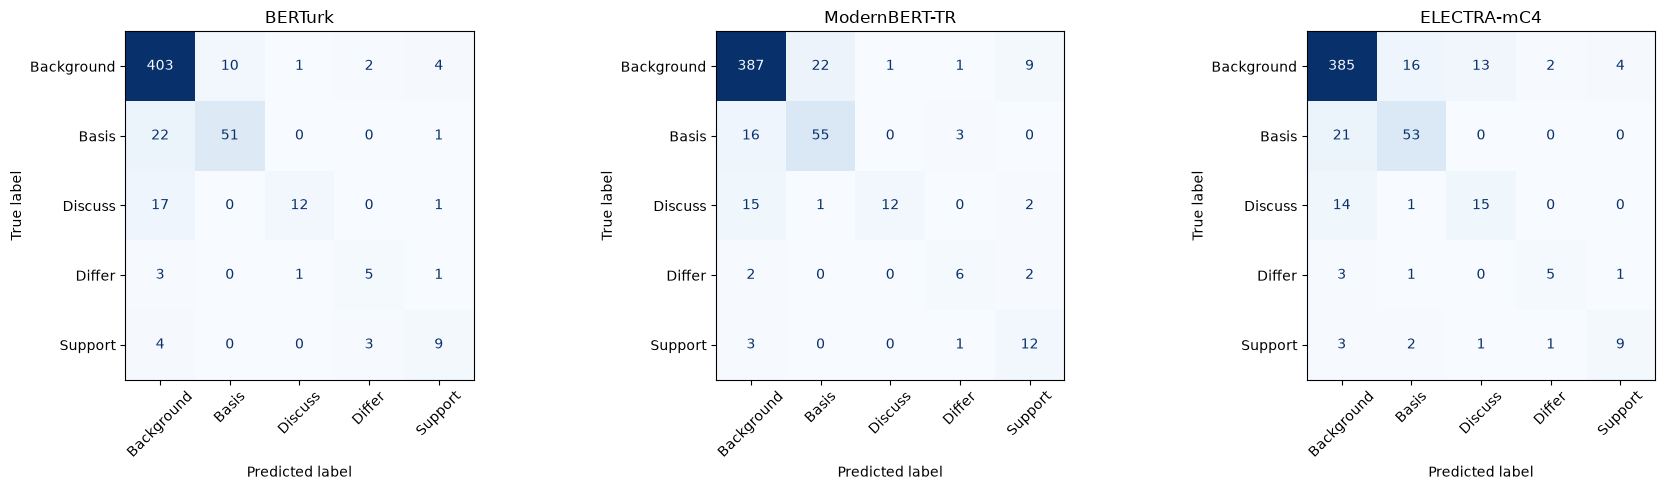

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("BERTurk", preds),
    ("ModernBERT-TR", preds_mb),
    ("ELECTRA-mC4", preds_el),
]

for ax, (name, model_preds) in zip(axes, models_preds):
    ConfusionMatrixDisplay.from_predictions(
        test_pub["citation_intent"],
        model_preds,
        display_labels=list(LABEL_NAMES.values()),
        cmap="Blues",
        colorbar=False,
        ax=ax,
        xticks_rotation=45,
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", dpi=150)
plt.show()

All three models share the same dominant error: ~50% of Discuss examples are misclassified as Background (BERTurk 17/30, ModernBERT-TR 15/30, ELECTRA 14/30) — a model-agnostic weakness, likely because Discuss lacks the strong lexical cues that separate Basis/Differ/Support from Background. ModernBERT-TR has the best minority-class recall (Differ 6/10, Support 12/16), matching its Macro F1 edge. Basis is the best-handled minority class across all models (69-74% correct).